In [4]:
import torch 
import torch.nn as nn 
import torch.optim as optim 
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader 
import matplotlib.pyplot as plt 

In [9]:
# Data loading with transforms 

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_set = datasets.CIFAR10(root='./data', train=True, 
                            download=True, transform = transform) 

val_set = datasets.CIFAR10(root='./data', train=False, 
                            download=True, transform = transform) 

train_loader = DataLoader(train_set, batch_size = 64, shuffle = True) 
val_loader = DataLoader(val_set, batch_size = 64, shuffle = False) 

In [17]:
# Define a simple NN 

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__() 
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), # 32/2 --> 16*16 
            nn.Conv2d(32, 64, kernel_size = 3, padding=1), 
            nn.ReLU(),
            nn.MaxPool2d(2) # 16/2 --> 8*8 
        )

        self.classifier = nn.Sequential(
            nn.Flatten(), 
            nn.Linear(64*8*8, 256),
            nn.ReLU(), 
            nn.Dropout(0.5), 
            nn.Linear(256, 10) 
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x) 
        return x 


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)  # move to GPU 
print(model )
print(device)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)
cuda


In [18]:
# Loss and optimizer 

criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001) 

In [19]:
# Training loop 
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct = 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item() 
    return total_loss / len(loader), correct / len(loader.dataset)


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            correct += (outputs.argmax(1) == labels).sum().item()
    return total_loss / len(loader), correct/ len(loader.dataset)

In [20]:
train_loss, train_acc = [], [] 
val_loss, val_acc = [], [] 

for epoch in range(10):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion) 
    va_loss, va_acc = evaluate(model, val_loader, criterion)
    train_loss.append(tr_loss) ; train_acc.append(tr_acc) 
    val_loss.append(va_loss) ; val_acc.append(va_acc) 
    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss: {tr_loss:.3f} Acc: {tr_acc:.3f} | "
        f"Val Loss: {va_loss:.3f} Acc: {va_acc:.3f}"
    )
        

Epoch  1 | Train Loss: 1.455 Acc: 0.475 | Val Loss: 1.091 Acc: 0.620
Epoch  2 | Train Loss: 1.095 Acc: 0.613 | Val Loss: 0.937 Acc: 0.673
Epoch  3 | Train Loss: 0.950 Acc: 0.661 | Val Loss: 0.863 Acc: 0.698
Epoch  4 | Train Loss: 0.847 Acc: 0.703 | Val Loss: 0.814 Acc: 0.715
Epoch  5 | Train Loss: 0.777 Acc: 0.726 | Val Loss: 0.787 Acc: 0.726
Epoch  6 | Train Loss: 0.709 Acc: 0.748 | Val Loss: 0.774 Acc: 0.729
Epoch  7 | Train Loss: 0.654 Acc: 0.767 | Val Loss: 0.755 Acc: 0.742
Epoch  8 | Train Loss: 0.597 Acc: 0.788 | Val Loss: 0.753 Acc: 0.748
Epoch  9 | Train Loss: 0.555 Acc: 0.800 | Val Loss: 0.765 Acc: 0.749
Epoch 10 | Train Loss: 0.507 Acc: 0.817 | Val Loss: 0.787 Acc: 0.745


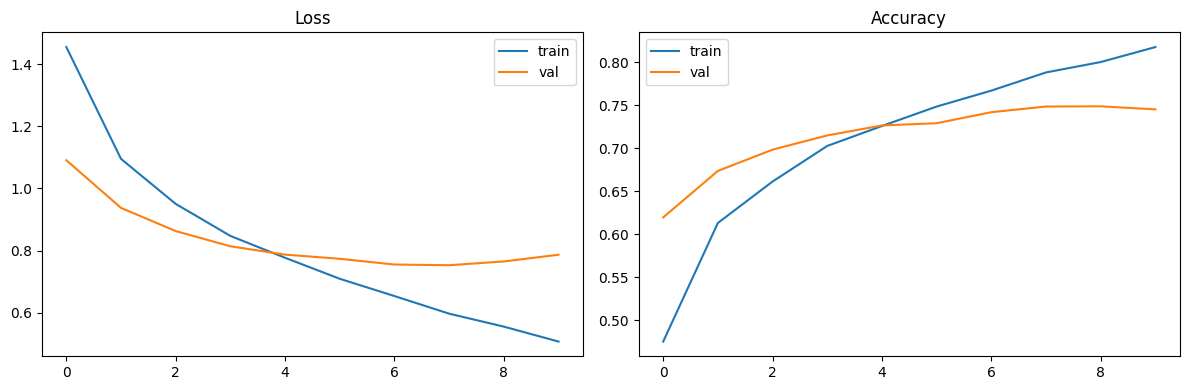

In [22]:
# Step 7 — Plot curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_loss, label='train'); ax1.plot(val_loss, label='val')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(train_acc, label='train'); ax2.plot(val_acc, label='val')
ax2.set_title('Accuracy'); ax2.legend()
plt.tight_layout(); plt.savefig('training_curves.png'); plt.show()